<a href="https://colab.research.google.com/github/AbdulrahmanB-25/Understanding_Data_using_Statistics/blob/main/Understanding_Data_using_Statistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================================
# Import Libraries
# ======================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ======================================================
# Load the Palmer Penguins Dataset
# ======================================================

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"

df = pd.read_csv(url)

# Display first rows
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
# Dataset information
df.info()

# Descriptive statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


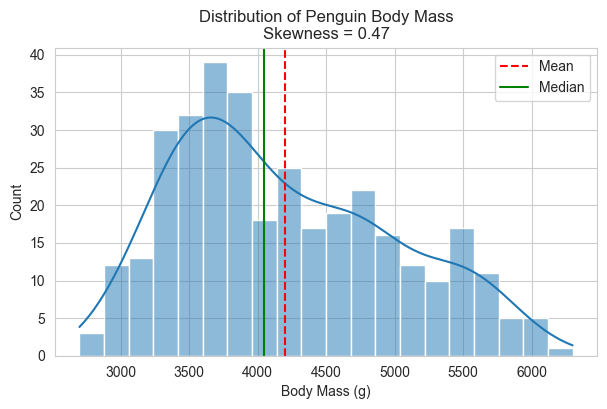

In [ ]:
# Calculate basic statistics for penguin body mass
mean_mass = df["body_mass_g"].mean()      # average body mass
median_mass = df["body_mass_g"].median()  # middle value of body mass
skew_mass = df["body_mass_g"].skew()      # measure of skewness (distribution direction)

# Create figure with specific size
plt.figure(figsize=(7,4))

# Plot histogram to show distribution of body mass
# bins=20 divides the data into 20 intervals
# kde=True adds a smooth density curve
sns.histplot(df["body_mass_g"], bins=20, kde=True)

# Add vertical line for mean
plt.axvline(mean_mass, color="red", linestyle="--", label="Mean")

# Add vertical line for median
plt.axvline(median_mass, color="green", label="Median")

# Title includes skewness value to show if distribution is symmetric or skewed
plt.title(f"Distribution of Penguin Body Mass\nSkewness = {skew_mass:.2f}")

# Axis labels
plt.xlabel("Body Mass (g)")
plt.ylabel("Count")

# Show legend for mean and median lines
plt.legend()

# Display the plot
plt.show()

C:\Users\faisa\AppData\Local\Temp\ipykernel_27920\3478751078.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


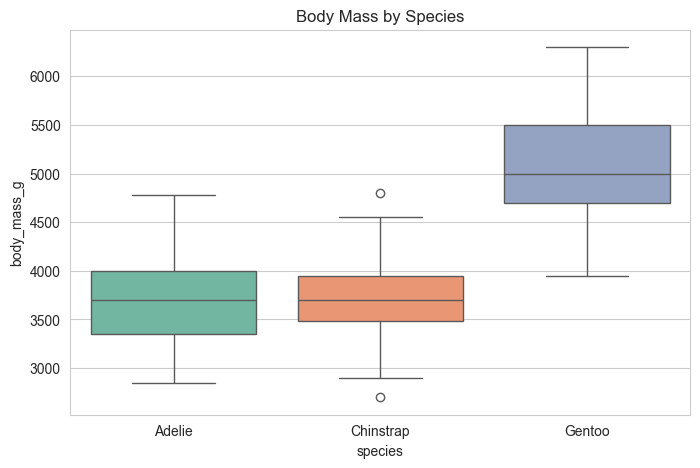

In [ ]:
# Create a figure with a specific size for better visibility
plt.figure(figsize=(8,5))

# Boxplot to compare body mass distribution between penguin species
sns.boxplot(
    data=df,          # dataset
    x="species",      # categorical variable (penguin species)
    y="body_mass_g",  # numeric variable (body mass in grams)
    palette="Set2"    # color palette for better visualization
)

# Title of the plot
plt.title("Body Mass by Species")

# Display the plot
plt.show()

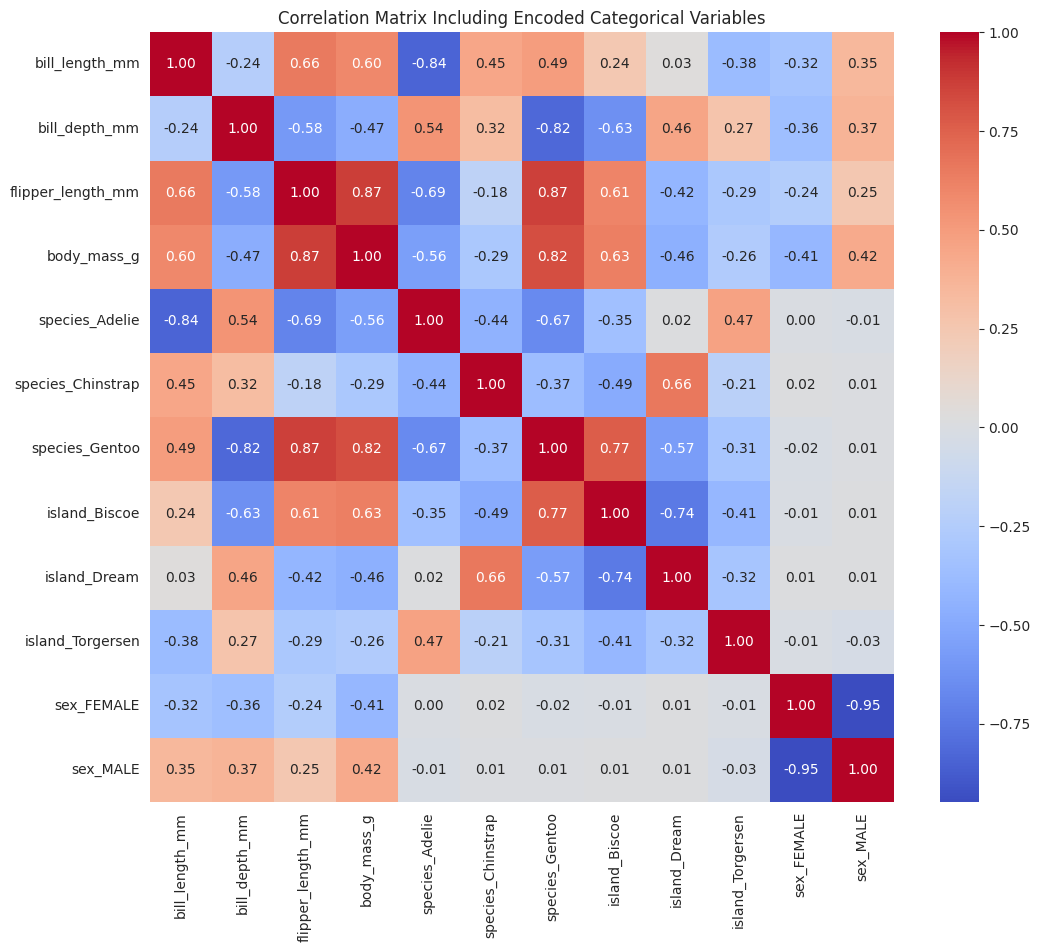

In [ ]:
#===============================================

#-------------------Member 4

#===============================================

# Select columns we want
df_new = df[[
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
    "species",
    "island",
    "sex"
]]

# Encode categorical variables
df_new = pd.get_dummies(df_new, columns=["species", "island", "sex"])

# Remove missing values
df_new = df_new.dropna()

# Compute correlation matrix
corr_matrix = df_new.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Matrix Including Encoded Categorical Variables")
plt.show()